# Wigner Function of |1⟩ Under Random Displacement Noise

The single-photon Fock state $|1\rangle$ has a **negative** Wigner function at the origin:

$$W_1(q, p) = \frac{2}{\pi}(4r^2 - 1)\,e^{-2r^2}, \qquad W_1(0,0) = -\frac{2}{\pi} \approx -0.637$$

where $r^2 = q^2 + p^2$. Random displacement noise convolves the Wigner function with the noise distribution:

$$W_\text{noisy}(q, p) = \iint P(\beta_q, \beta_p)\, W_1(q - \beta_q,\, p - \beta_p)\, d\beta_q\, d\beta_p$$

The noise distribution from the paper is $P(\beta_q, \beta_p) = G(\beta_q, \sigma)\,G(\beta_p, \sigma)$, a 2D Gaussian with variance $\sigma^2/2$ per quadrature.

The value at the origin evolves **analytically** as:

$$W_\text{noisy}(0, 0) = \frac{2(2\sigma^2 - 1)}{\pi(2\sigma^2 + 1)^2}$$

Negativity disappears at $\sigma^* = 1/\sqrt{2} \approx 0.707$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# ── Phase-space grid ─────────────────────────────────────────────
N  = 400
L  = 4.0
q  = np.linspace(-L, L, N)
dq = q[1] - q[0]
Q, P_grid = np.meshgrid(q, q)
r2 = Q**2 + P_grid**2

# ── Single-photon Wigner function ────────────────────────────────
W1 = (2 / np.pi) * (4 * r2 - 1) * np.exp(-2 * r2)

def noisy_wigner(sigma):
    """Convolve W1 with Gaussian displacement noise P(beta) = G(beta_q,sigma)*G(beta_p,sigma)."""
    kernel = np.exp(-(Q**2 + P_grid**2) / sigma**2) / (np.pi * sigma**2)
    return fftconvolve(W1, kernel, mode='same') * dq**2

def W0_exact(sigma):
    """Analytical W_noisy(0,0) = 2(2σ²-1) / π(2σ²+1)²"""
    return 2 * (2*sigma**2 - 1) / (np.pi * (2*sigma**2 + 1)**2)

sigma_star = 1 / np.sqrt(2)   # threshold: W(0,0) = 0

# Compute for three noise levels
sigmas       = [0.4, sigma_star, 1.0]
W_noisy_list = [noisy_wigner(s) for s in sigmas]

print(f"Negativity threshold: σ* = 1/√2 = {sigma_star:.4f}")
print(f"\nClean state:   W(0,0) = {W1[N//2, N//2]:.4f}  (exact: {-2/np.pi:.4f})")
for s, W_n in zip(sigmas, W_noisy_list):
    marker = '  ← zero crossing' if abs(s - sigma_star) < 0.01 else ''
    print(f"σ = {s:.3f}:    W(0,0) = {W_n[N//2, N//2]:.4f}  (exact: {W0_exact(s):.4f}){marker}")

Negativity threshold: σ* = 1/√2 = 0.7071

Clean state:   W(0,0) = -0.6359  (exact: -0.6366)
σ = 0.400:    W(0,0) = -0.2485  (exact: -0.2485)
σ = 0.707:    W(0,0) = -0.0000  (exact: -0.0000)  ← zero crossing
σ = 1.000:    W(0,0) = 0.0707  (exact: 0.0707)


## Wigner Function Maps

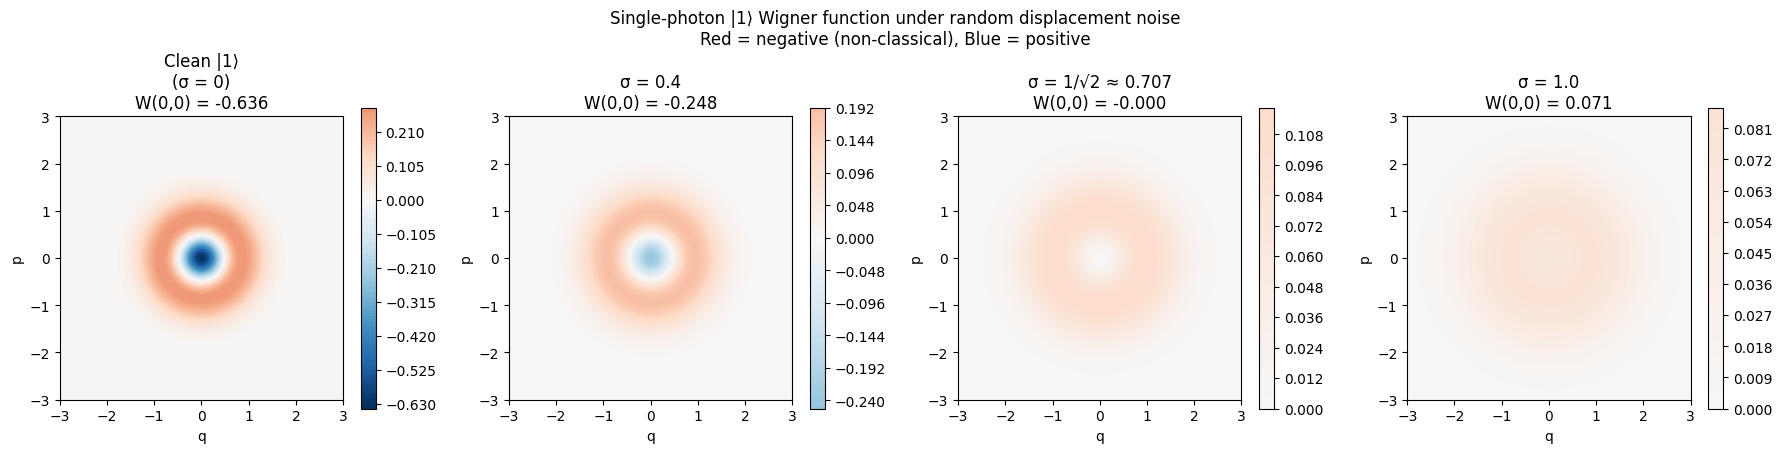

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

all_W  = [W1] + W_noisy_list
labels = ['Clean |1⟩\n(σ = 0)', 'σ = 0.4', f'σ = 1/√2 ≈ {sigma_star:.3f}', 'σ = 1.0']
vmax   = np.abs(W1).max()

for ax, W, label in zip(axes, all_W, labels):
    cont = ax.contourf(Q, P_grid, W, levels=80, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(cont, ax=ax, shrink=0.85)
    W0 = W[N//2, N//2]
    sign = '−' if W0 < 0 else '+'
    ax.set_title(f'{label}\nW(0,0) = {W0:.3f}')
    ax.set_xlabel('q')
    ax.set_ylabel('p')
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.suptitle('Single-photon |1⟩ Wigner function under random displacement noise\n'
             'Red = negative (non-classical), Blue = positive', fontsize=12)
plt.tight_layout()
plt.show()

## Cross-Section and Negativity Threshold

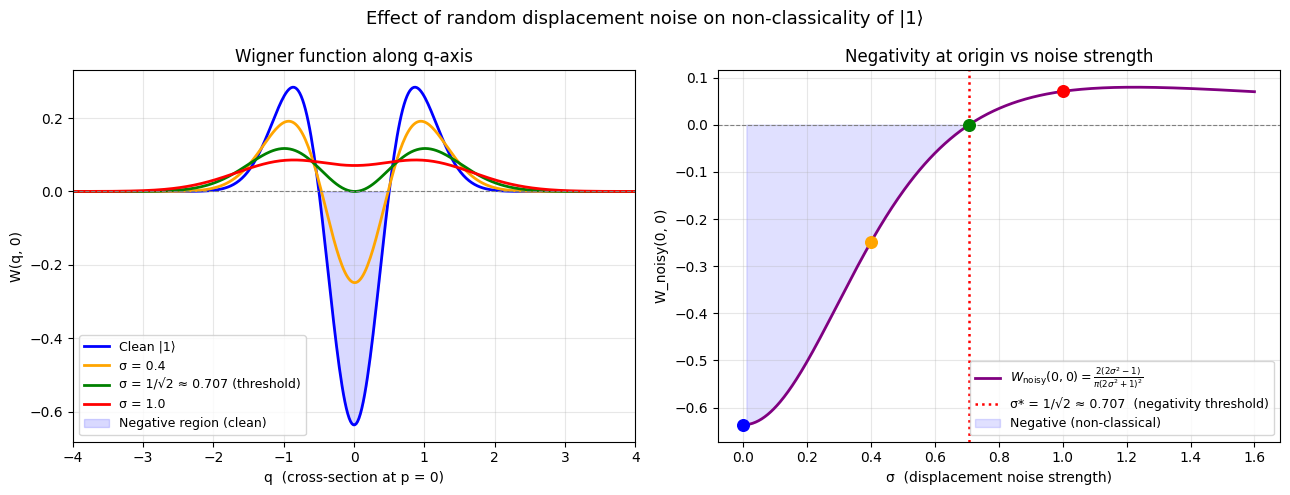

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: cross-section through origin (p = 0) ───────────────────
mid = N // 2
ax1.plot(q, W1[mid, :], color='blue', linewidth=2, label='Clean |1⟩')
cs = ['orange', 'green', 'red']
for W_n, s, c in zip(W_noisy_list, sigmas, cs):
    lbl = f'σ = 1/√2 ≈ {s:.3f} (threshold)' if abs(s - sigma_star) < 0.01 else f'σ = {s}'
    ax1.plot(q, W_n[mid, :], color=c, linewidth=2, label=lbl)
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.fill_between(q, W1[mid, :], 0, where=(W1[mid, :] < 0),
                 color='blue', alpha=0.15, label='Negative region (clean)')
ax1.set_xlabel('q  (cross-section at p = 0)')
ax1.set_ylabel('W(q, 0)')
ax1.set_title('Wigner function along q-axis')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(-4, 4)

# ── Right: W(0,0) vs sigma — analytical formula ──────────────────
sigma_range = np.linspace(0.01, 1.6, 500)
ax2.plot(sigma_range, W0_exact(sigma_range), color='purple', linewidth=2,
         label=r'$W_{\rm noisy}(0,0) = \frac{2(2\sigma^2-1)}{\pi(2\sigma^2+1)^2}$')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axvline(sigma_star, color='red', linestyle=':', linewidth=1.8,
            label=f'σ* = 1/√2 ≈ {sigma_star:.3f}  (negativity threshold)')

# Mark the three computed points
for s, c in zip([0.0] + sigmas, ['blue', 'orange', 'green', 'red']):
    ax2.scatter([s], [W0_exact(max(s, 1e-4))], color=c, s=70, zorder=5)

ax2.fill_between(sigma_range, W0_exact(sigma_range), 0,
                 where=(W0_exact(sigma_range) < 0),
                 color='blue', alpha=0.12, label='Negative (non-classical)')
ax2.set_xlabel('σ  (displacement noise strength)')
ax2.set_ylabel('W_noisy(0, 0)')
ax2.set_title('Negativity at origin vs noise strength')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Effect of random displacement noise on non-classicality of |1⟩', fontsize=13)
plt.tight_layout()
plt.show()

## Effect of QEC on Wigner Negativity

QEC changes the **effective displacement distribution** $P_\text{corr}(\beta)$ — it becomes narrower and non-Gaussian. Since the noisy Wigner function is a convolution of $W_1$ with $P$, a narrower $P_\text{corr}$ means less smearing, which **preserves more negativity**.

Two protocols from the paper:

**Squeezing + 1-qubit QEC** (Fig. 1 of paper):
- Squeeze mode before error: $\sigma_q \to \sigma e^{2\zeta_\text{opt}}$ (reduced), $\sigma_p \to \sigma e^{-2\zeta_\text{opt}}$ (amplified)
- Apply 1-qubit QEC on $p$-quadrature only — total variance reduced by **20.5%**

**2-qubit QEC**:
- One qubit corrects $p$, one corrects $q$, independently — total variance reduced by **36.8%**

We average over both measurement outcomes ($\pm Y$) since both are equally likely and mirror-symmetric.

In [9]:
def G(x, sigma):
    return np.exp(-x**2 / sigma**2) / (np.sqrt(np.pi) * sigma)

zeta_opt = (1/8) * np.log(1 - np.exp(-1))   # optimal squeezing ≈ −0.0574

def apply_distr(K):
    """Convolve W1 with normalized effective displacement distribution K."""
    return fftconvolve(W1, K, mode='same') * dq**2

def K_no_qec(sigma):
    K = np.exp(-(Q**2 + P_grid**2) / sigma**2) / (np.pi * sigma**2)
    return K / (K.sum() * dq**2)

def K_squeezing_qec(sigma):
    """Squeezing + 1-qubit QEC on p, averaged over ±Y outcomes."""
    sigma_q = sigma * np.exp(2 * zeta_opt)
    sigma_p = sigma * np.exp(-2 * zeta_opt)
    a_p  = 1 / (np.sqrt(8) * sigma_p)
    bbar = 2 * a_p * sigma_p**2 * np.exp(-4 * a_p**2 * sigma_p**2)
    P_plus  = G(P_grid + bbar, sigma_p) * (1 + np.sin(4*a_p*(P_grid + bbar)))
    P_minus = G(P_grid - bbar, sigma_p) * (1 - np.sin(4*a_p*(P_grid - bbar)))
    K = G(Q, sigma_q) * np.clip(0.5*(P_plus + P_minus), 0, None)
    return K / (K.sum() * dq**2)

def K_2qubit_qec(sigma):
    """2-qubit QEC on both quadratures, averaged over measurement outcomes."""
    a    = 1 / (np.sqrt(8) * sigma)
    bbar = 2 * a * sigma**2 * np.exp(-4 * a**2 * sigma**2)
    P_p = 0.5 * (G(P_grid + bbar, sigma) * (1 + np.sin(4*a*(P_grid + bbar))) +
                 G(P_grid - bbar, sigma) * (1 - np.sin(4*a*(P_grid - bbar))))
    P_q = 0.5 * (G(Q - bbar, sigma) * (1 - np.sin(4*a*(Q - bbar))) +
                 G(Q + bbar, sigma) * (1 + np.sin(4*a*(Q + bbar))))
    K = np.clip(P_q * P_p, 0, None)
    return K / (K.sum() * dq**2)

# Compute at σ = 0.7 (right at the no-QEC threshold σ* = 1/√2 ≈ 0.707)
sigma = 0.3
mid   = N // 2

W_noise = apply_distr(K_no_qec(sigma))
W_sq    = apply_distr(K_squeezing_qec(sigma))
W_2q    = apply_distr(K_2qubit_qec(sigma))

print(f"σ = {sigma}   (threshold without QEC: σ* = 1/√2 = {1/np.sqrt(2):.4f})")
print(f"Clean |1⟩:              W(0,0) = {W1[mid,mid]:.4f}  (exact: {-2/np.pi:.4f})")
print(f"No QEC:                 W(0,0) = {W_noise[mid,mid]:.4f}  (exact: {W0_exact(sigma):.4f})")
print(f"Squeezing + 1-qubit:    W(0,0) = {W_sq[mid,mid]:.4f}")
print(f"2-qubit QEC:            W(0,0) = {W_2q[mid,mid]:.4f}")

σ = 0.3   (threshold without QEC: σ* = 1/√2 = 0.7071)
Clean |1⟩:              W(0,0) = -0.6359  (exact: -0.6366)
No QEC:                 W(0,0) = -0.3749  (exact: -0.3749)
Squeezing + 1-qubit:    W(0,0) = -0.4230
2-qubit QEC:            W(0,0) = -0.4631


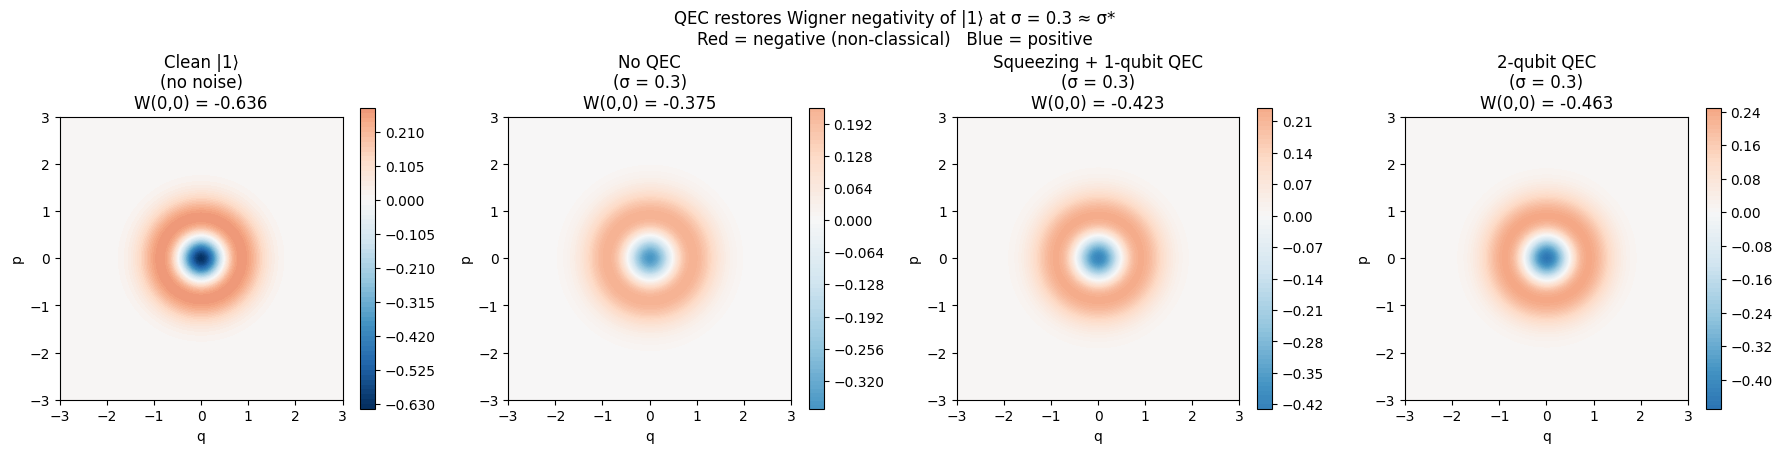

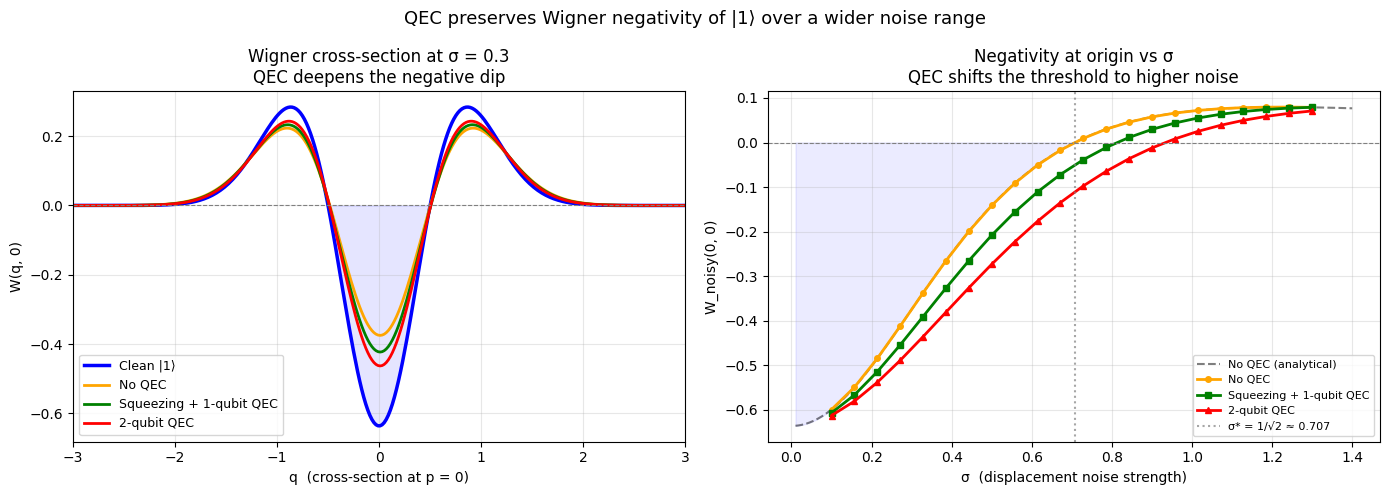

In [10]:
# ── Figure 1: Wigner maps comparing all protocols ────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
vmax = np.abs(W1).max()

for ax, W, title in zip(axes,
                         [W1, W_noise, W_sq, W_2q],
                         ['Clean |1⟩\n(no noise)',
                          f'No QEC\n(σ = {sigma})',
                          f'Squeezing + 1-qubit QEC\n(σ = {sigma})',
                          f'2-qubit QEC\n(σ = {sigma})']):
    cont = ax.contourf(Q, P_grid, W, levels=80, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(cont, ax=ax, shrink=0.85)
    ax.set_title(f'{title}\nW(0,0) = {W[mid,mid]:.3f}')
    ax.set_xlabel('q')
    ax.set_ylabel('p')
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.suptitle(f'QEC restores Wigner negativity of |1⟩ at σ = {sigma} ≈ σ*\n'
             'Red = negative (non-classical)   Blue = positive', fontsize=12)
plt.tight_layout()
plt.show()

# ── Figure 2: Cross-section + W(0,0) vs σ scan ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(q, W1[mid, :],      color='blue',   linewidth=2.5, label='Clean |1⟩')
ax1.plot(q, W_noise[mid, :], color='orange', linewidth=2,   label='No QEC')
ax1.plot(q, W_sq[mid, :],    color='green',  linewidth=2,   label='Squeezing + 1-qubit QEC')
ax1.plot(q, W_2q[mid, :],    color='red',    linewidth=2,   label='2-qubit QEC')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.fill_between(q, W1[mid, :], 0, where=(W1[mid, :] < 0), color='blue', alpha=0.1)
ax1.set_xlabel('q  (cross-section at p = 0)')
ax1.set_ylabel('W(q, 0)')
ax1.set_title(f'Wigner cross-section at σ = {sigma}\nQEC deepens the negative dip')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(-3, 3)

sigmas_scan = np.linspace(0.1, 1.3, 22)
W0_noise_scan, W0_sq_scan, W0_2q_scan = [], [], []
for s in sigmas_scan:
    W0_noise_scan.append(apply_distr(K_no_qec(s))[mid, mid])
    W0_sq_scan.append(apply_distr(K_squeezing_qec(s))[mid, mid])
    W0_2q_scan.append(apply_distr(K_2qubit_qec(s))[mid, mid])

sigma_range = np.linspace(0.01, 1.4, 400)
ax2.plot(sigma_range, W0_exact(sigma_range), 'k--', linewidth=1.5, alpha=0.5, label='No QEC (analytical)')
ax2.plot(sigmas_scan, W0_noise_scan, 'o-', color='orange', linewidth=2, markersize=4, label='No QEC')
ax2.plot(sigmas_scan, W0_sq_scan,    's-', color='green',  linewidth=2, markersize=4, label='Squeezing + 1-qubit QEC')
ax2.plot(sigmas_scan, W0_2q_scan,    '^-', color='red',    linewidth=2, markersize=4, label='2-qubit QEC')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axvline(1/np.sqrt(2), color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
            label=f'σ* = 1/√2 ≈ {1/np.sqrt(2):.3f}')
ax2.fill_between(sigma_range, W0_exact(sigma_range), 0,
                 where=(W0_exact(sigma_range) < 0), color='blue', alpha=0.08)
ax2.set_xlabel('σ  (displacement noise strength)')
ax2.set_ylabel('W_noisy(0, 0)')
ax2.set_title('Negativity at origin vs σ\nQEC shifts the threshold to higher noise')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('QEC preserves Wigner negativity of |1⟩ over a wider noise range', fontsize=13)
plt.tight_layout()
plt.show()